In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_blobs, make_moons, make_circles

In [ ]:
X, y = make_blobs(n_samples = 200, n_features = 2, centers = 4, cluster_std = 1.1, random_state=42)

df = pd.DataFrame(np.hstack((X,y.reshape(-1,1))))

df.columns = ['Feature 1', 'Feature 2', 'Cluster']

df['Cluster'] = df['Cluster'].astype(int)

df.head()

,Feature 1,Feature 2,Cluster
0,6.692231,2.494386,1
1,-5.390917,9.918379,0
2,-8.851799,6.336543,3
3,-10.431221,5.775313,3
4,-7.527928,-5.945547,2


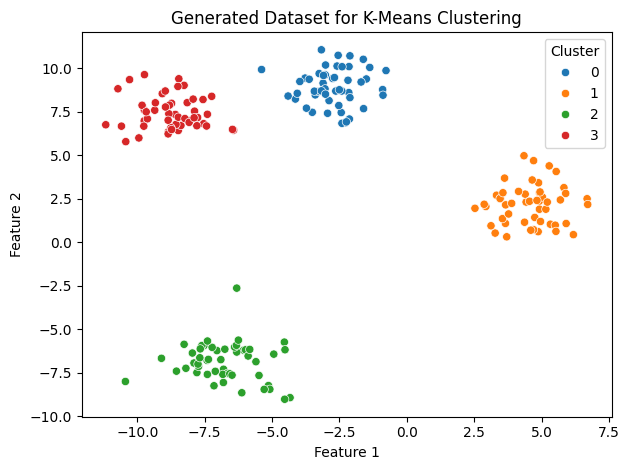

In [ ]:
sns.scatterplot(x = df.iloc[:,0], y = df.iloc[:,1], hue = df['Cluster'], palette ='tab10')
plt.title("Generated Dataset for K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

In [ ]:
df.drop(columns = ['Cluster'], inplace = True)

scaler = StandardScaler()

df = pd.DataFrame(data = scaler.fit_transform(df), columns = scaler.get_feature_names_out())

df.head()

,Feature 1,Feature 2
0,1.941664,-0.063832
1,-0.381640,1.120834
2,-1.047087,0.549271
3,-1.350772,0.459714
4,-0.792537,-1.410615


#Elbow Method & Silhouette Score

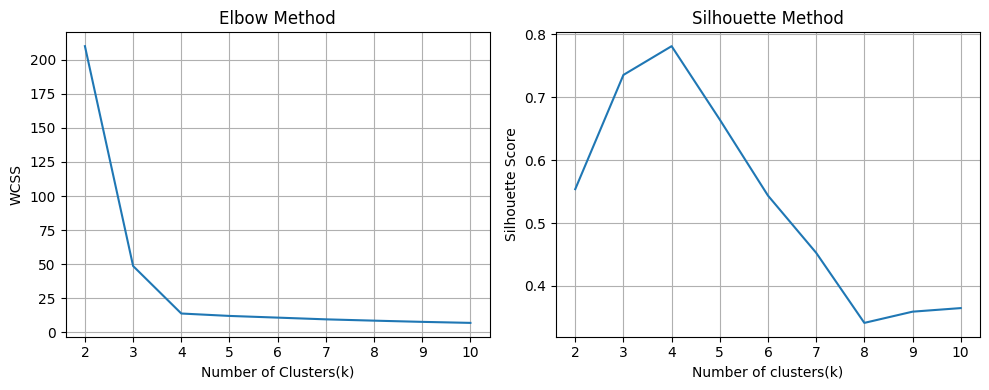

In [ ]:
X = df.values

wcss = []
sil_score = []

for k in range(2, 11):

    kmeans = KMeans(n_init = 20, n_clusters = k, max_iter = 300)
    y_labels = kmeans.fit_predict(X)

    wcss.append(kmeans.inertia_)
    sil_score.append(silhouette_score(X, labels = y_labels))


fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))

# Elbow Method
sns.lineplot(x = range(2,11), y =  wcss, ax = ax1)
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of Clusters(k)')
ax1.set_ylabel('WCSS')
ax1.grid(True)

# Silhouette Score
sns.lineplot(x = range(2,11), y = sil_score, ax = ax2)
ax2.set_title('Silhouette Method')
ax2.set_xlabel('Number of clusters(k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True)

# Improce Spacing
plt.tight_layout()
plt.show()

In [ ]:
kmeans = KMeans(n_init = 10, n_clusters = 4, init = 'k-means++', random_state = 42)

y_kmeans = kmeans.fit_predict(X)

df['y_kmeans'] = y_kmeans # particular point will go to which cluster

df.head()

,Feature 1,Feature 2,y_kmeans
0,1.941664,-0.063832,0
1,-0.381640,1.120834,1
2,-1.047087,0.549271,3
3,-1.350772,0.459714,3
4,-0.792537,-1.410615,2


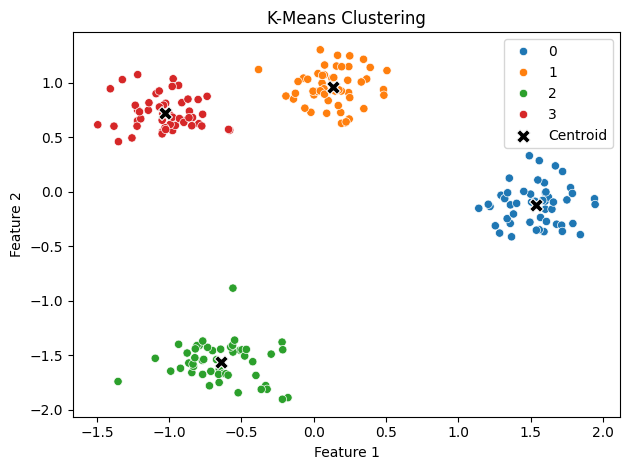

In [ ]:
sns.scatterplot(x = df.iloc[:,0], y = df.iloc[:,1], hue = df['y_kmeans'], palette ='tab10')

# Correct centroid plotting
sns.scatterplot(x = kmeans.cluster_centers_[:, 0], y = kmeans.cluster_centers_[:, 1], c = 'black', s = 100, marker = 'X', label = 'Centroid')

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.legend()
plt.show()

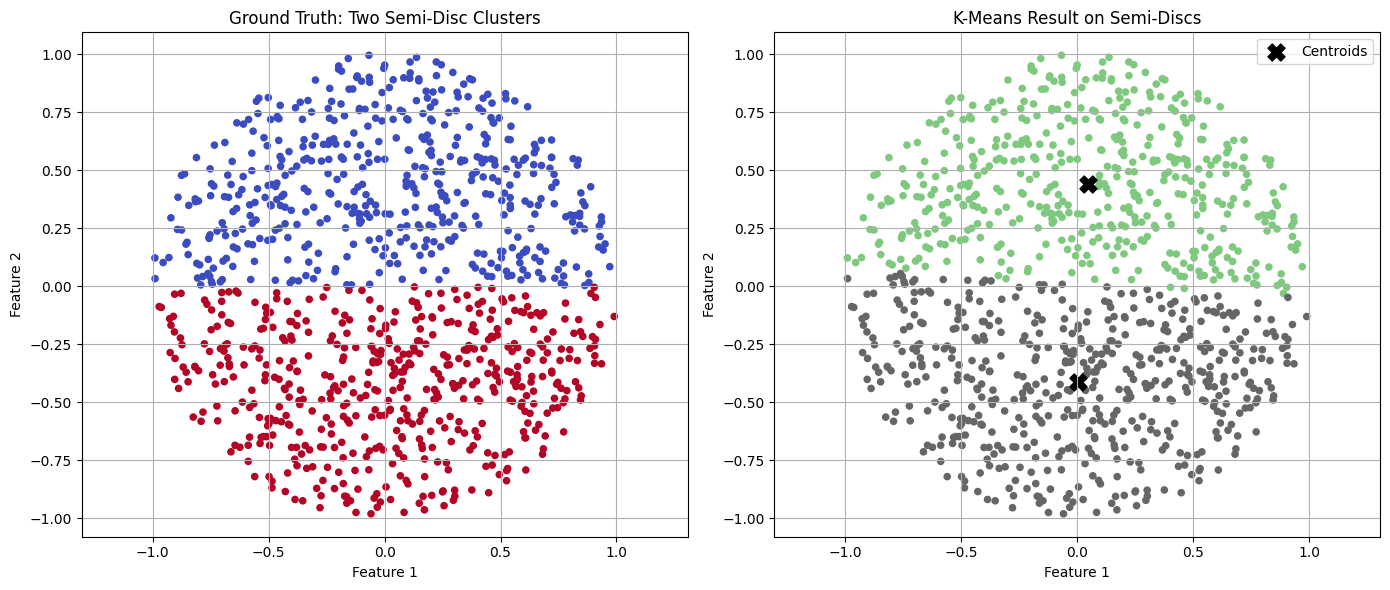

In [ ]:
n_samples = 1000
r = np.sqrt(np.random.rand(n_samples))           # sqrt for uniform distribution
theta = 2 * np.pi * np.random.rand(n_samples)    # angle

# Convert to Cartesian coordinates
x = r * np.cos(theta)
y = r * np.sin(theta)
X = np.column_stack((x, y))

# Ground truth labels based on y-coordinate (top/bottom)
y_true = (y < 0).astype(int)  # 0 for top, 1 for bottom (can reverse if needed)

# K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)
silhouette = silhouette_score(X, kmeans.labels_).round(2)

# Plot side by side
fig, axes = plt.subplots(ncols=2, figsize=(14, 6))

# Ground Truth
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='coolwarm', s=20)
axes[0].set_title("Ground Truth: Two Semi-Disc Clusters")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].axis('equal')
axes[0].grid(True)

# K-Means Result
axes[1].scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='Accent', s=20)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='black', marker='X', s=150, label='Centroids')
axes[1].set_title("K-Means Result on Semi-Discs")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()
axes[1].axis('equal')
axes[1].grid(True)

plt.tight_layout()
plt.show()

#Limitations of Elbow Method

##1.Subjectivity in Identifying the Elbow Point: The point where the interia starts decreasing at a slower rate can be open to interpretation and may not be clear-cut, especially in datasets where the decrease in inertia is gradual.

In [ ]:
X,y = make_moons(n_samples = 300, shuffle = True, noise = 0.1, random_state = 42)

df = pd.DataFrame(np.hstack((X,y.reshape(-1,1))))

df.columns = ['Feature 1', 'Feature 2', 'Cluster']

df['Cluster'] = df['Cluster'].astype(int)

df.head()

,Feature 1,Feature 2,Cluster
0,0.682988,-0.345203,1
1,2.040990,-0.131615,1
2,-0.139752,0.454391,1
3,0.885748,0.286342,0
4,1.182459,-0.497711,1


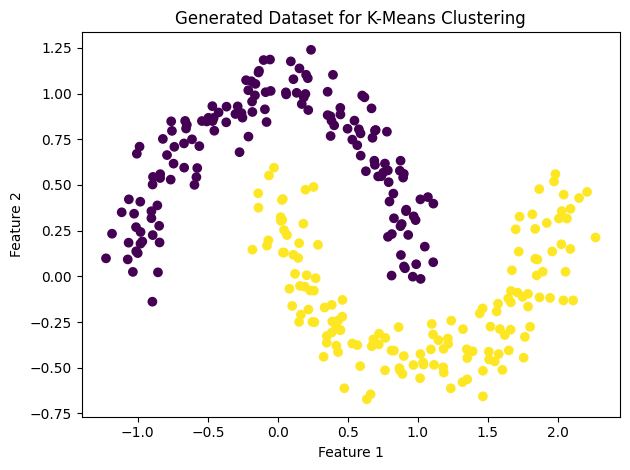

In [ ]:
plt.scatter(df['Feature 1'], df['Feature 2'], c = df['Cluster'])
plt.title("Generated Dataset for K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

In [ ]:
df.drop(columns = ['Cluster'], inplace = True)

scaler = StandardScaler()

df = pd.DataFrame(data = scaler.fit_transform(df), columns = scaler.get_feature_names_out())

df.head()

,Feature 1,Feature 2
0,0.208181,-1.197151
1,1.760142,-0.772118
2,-0.732068,0.394011
3,0.439900,0.059600
4,0.778989,-1.500635


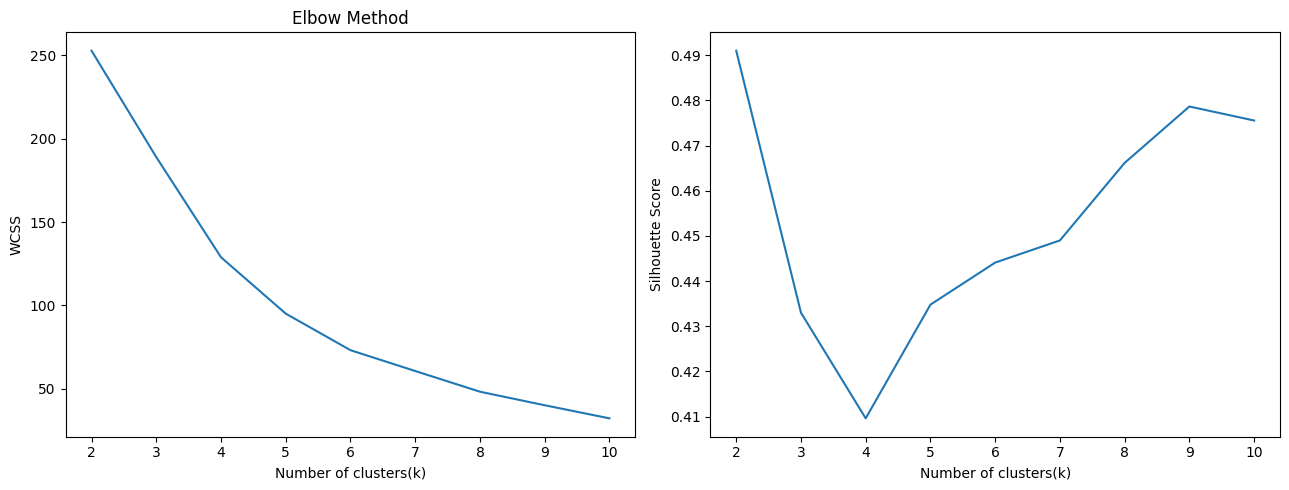

In [ ]:
# Elbow Method and Silhouette Score

X = df.values

wcss = []
sil_score = []

for k in range(2, 11):

    kmeans = KMeans(n_init = 10, n_clusters = k)
    y_labels = kmeans.fit_predict(X)

    wcss.append(kmeans.inertia_)
    sil_score.append(silhouette_score(X, labels = y_labels))

# Plotting figure
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (13,5))

# Elbow Method
sns.lineplot(x = range(2,11), y =  wcss, ax = ax1)
ax1.set_xlabel('Number of clusters(k)')
ax1.set_ylabel('WCSS')
ax1.set_title('Elbow Method')

# Silhouette Score
sns.lineplot(x = range(2,11), y = sil_score, ax = ax2)
ax2.set_xlabel('Number of clusters(k)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

## 2.Not Suitable for all datasets: The elbow method does not work well if the data is not very clustered or if the clusters have an irregular shape. In such cases, elbow point might not be distinct, leading to ambiguity in choosing the right number of clusters.

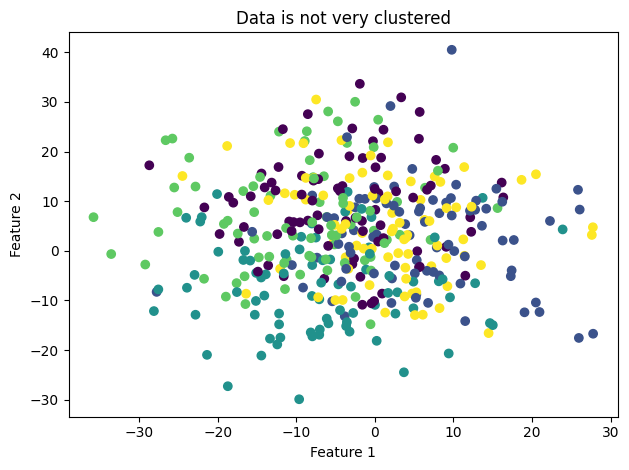

In [ ]:
X, y = make_blobs(n_samples = 400, n_features = 2, centers = 5, cluster_std = 10, random_state=42)

# Visualize the data
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.title("Data is not very clustered")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

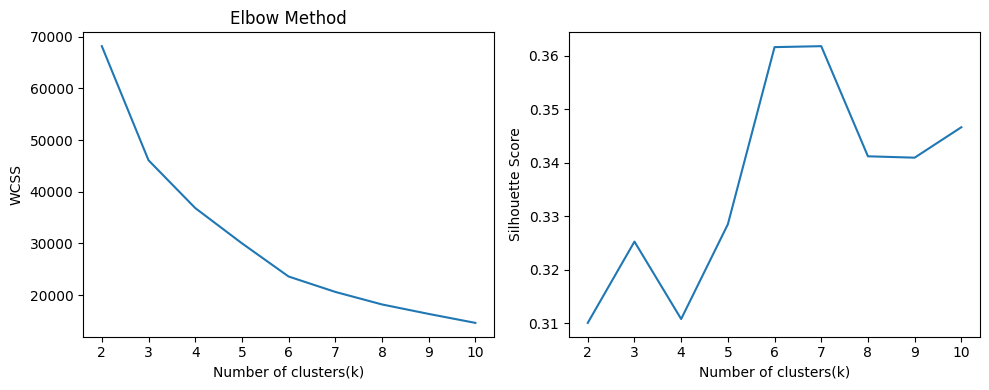

In [ ]:
wcss = []
sil_score = []

for k in range(2, 11):

    kmeans = KMeans(n_init = 10, n_clusters = k)
    y_labels = kmeans.fit_predict(X)

    wcss.append(kmeans.inertia_)
    sil_score.append(silhouette_score(X, labels = y_labels))


fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))

# Elbow Method
sns.lineplot(x = range(2,11), y =  wcss, ax = ax1)
ax1.set_xlabel('Number of clusters(k)')
ax1.set_ylabel('WCSS')
ax1.set_title('Elbow Method')

# Silhouette Score
sns.lineplot(x = range(2,11), y = sil_score, ax = ax2)
ax2.set_xlabel('Number of clusters(k)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

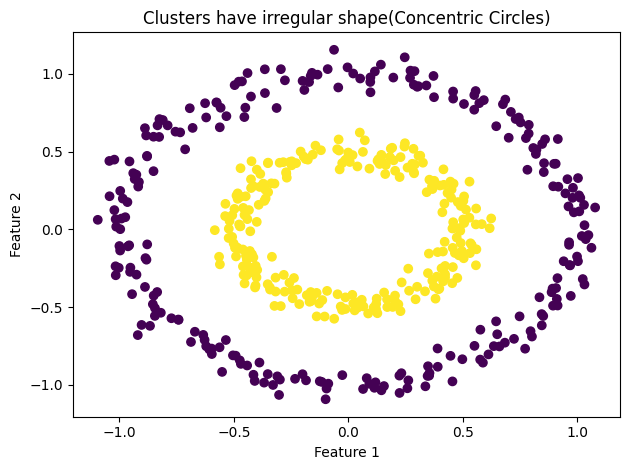

In [ ]:
# Generate concentric circles
X, y = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

# Visualize the data
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.title('Clusters have irregular shape(Concentric Circles)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

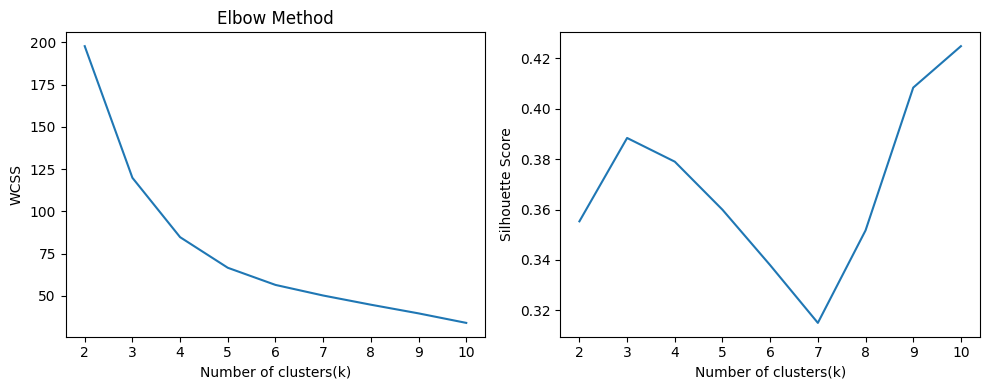

In [ ]:
wcss = []
sil_score = []

for k in range(2, 11):

    kmeans = KMeans(n_init = 10, n_clusters = k)
    y_labels = kmeans.fit_predict(X)

    wcss.append(kmeans.inertia_)
    sil_score.append(silhouette_score(X, labels = y_labels))


fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))

# Elbow Method
sns.lineplot(x = range(2,11), y =  wcss, ax = ax1)
ax1.set_xlabel('Number of clusters(k)')
ax1.set_ylabel('WCSS')
ax1.set_title('Elbow Method')

# Silhouette Score
sns.lineplot(x = range(2,11), y = sil_score, ax = ax2)
ax2.set_xlabel('Number of clusters(k)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

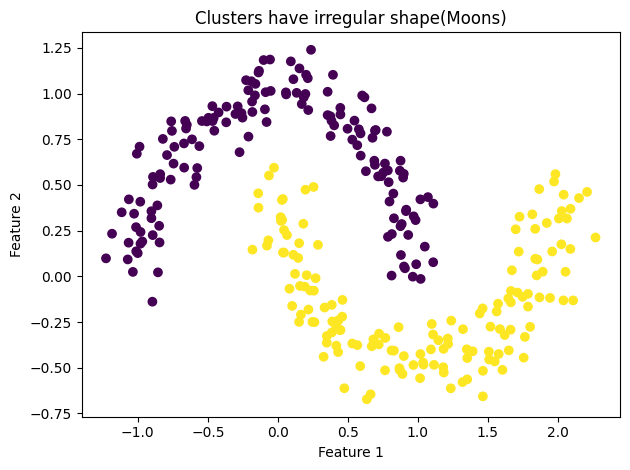

In [ ]:
X,y = make_moons(n_samples = 300, shuffle = True, noise = 0.1, random_state = 42)

# Visualize the data
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.title('Clusters have irregular shape(Moons)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

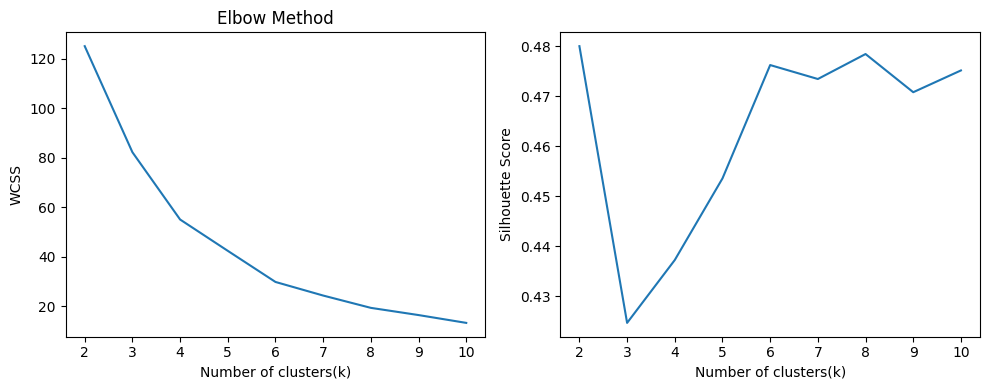

In [ ]:
wcss = []
sil_score = []

for k in range(2, 11):

    kmeans = KMeans(n_init = 10, n_clusters = k)
    y_labels = kmeans.fit_predict(X)

    wcss.append(kmeans.inertia_)
    sil_score.append(silhouette_score(X, labels = y_labels))


fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))

# Elbow Method
sns.lineplot(x = range(2,11), y =  wcss, ax = ax1)
ax1.set_xlabel('Number of clusters(k)')
ax1.set_ylabel('WCSS')
ax1.set_title('Elbow Method')

# Silhouette Score
sns.lineplot(x = range(2,11), y = sil_score, ax = ax2)
ax2.set_xlabel('Number of clusters(k)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

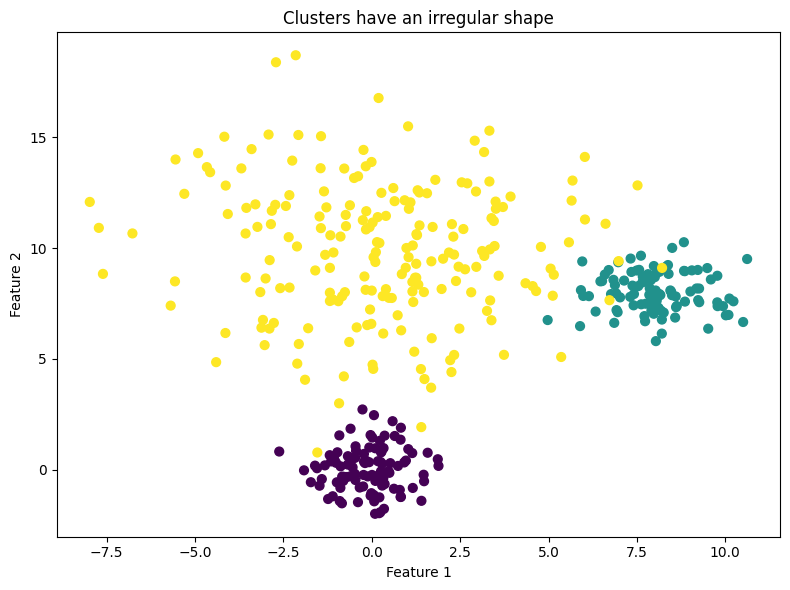

In [ ]:
# Define the parameters
centers = [(0, 0), (8, 8), (0, 10)]  # 3 clusters
cluster_std = [1.0, 1.0, 3.0]        # 3rd cluster is larger (more spread)

# Number of points per cluster
samples_per_cluster = [100, 100, 200]

# Generate each cluster separately
X_parts = []
y_parts = []

for i, (center, std, n_samples) in enumerate(zip(centers, cluster_std, samples_per_cluster)):
    X_blob, _ = make_blobs(n_samples=n_samples, centers=[center], cluster_std=std, random_state=42+i)
    X_parts.append(X_blob)
    y_parts.append(np.full(shape=n_samples, fill_value=i))

# Combine the clusters
X = np.vstack(X_parts)
y = np.hstack(y_parts)

# Plot the result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=40)
plt.title("Clusters have an irregular shape")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

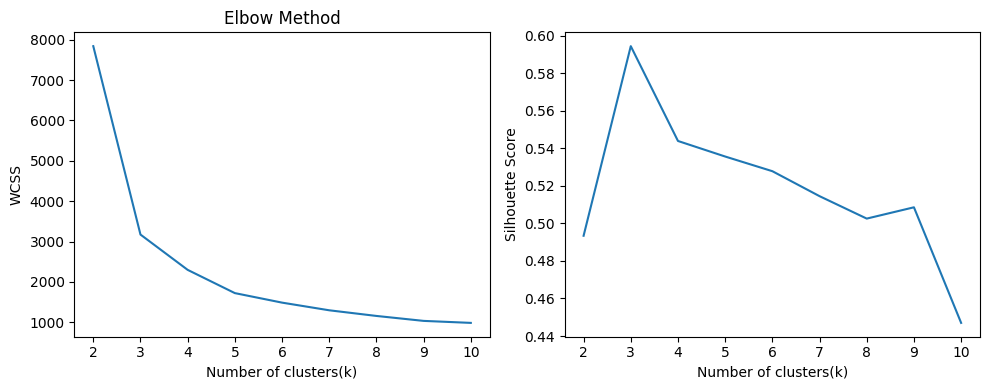

In [ ]:
wcss = []
sil_score = []

for k in range(2, 11):

    kmeans = KMeans(n_init = 10, n_clusters = k)
    y_labels = kmeans.fit_predict(X)

    wcss.append(kmeans.inertia_)
    sil_score.append(silhouette_score(X, labels = y_labels))


fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))

# Elbow Method
sns.lineplot(x = range(2,11), y =  wcss, ax = ax1)
ax1.set_xlabel('Number of clusters(k)')
ax1.set_ylabel('WCSS')
ax1.set_title('Elbow Method')

# Silhouette Score
sns.lineplot(x = range(2,11), y = sil_score, ax = ax2)
ax2.set_xlabel('Number of clusters(k)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

## 3.The elbow method can become less effective as the number of features in the dataset increases. High Dimensional data can make identification of a clear elbow more difficult

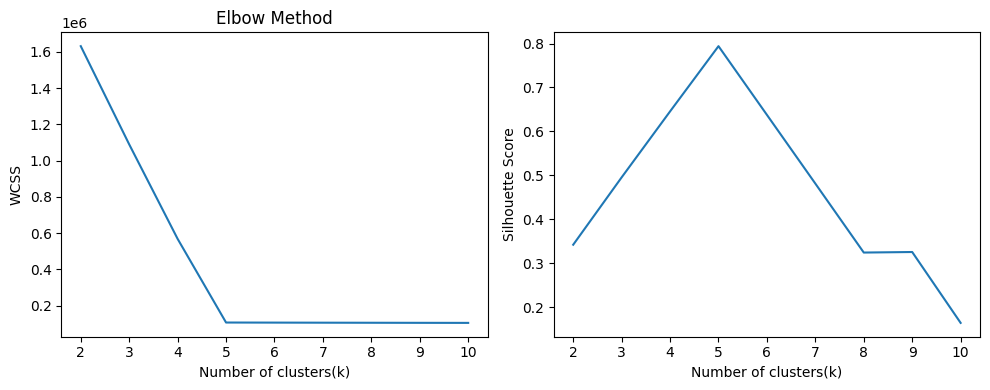

In [ ]:
X, y = make_blobs(n_samples = 500, n_features = 150, centers = 5, cluster_std = 1.2, random_state=42)

wcss = []
sil_score = []

for k in range(2, 11):

    kmeans = KMeans(n_init = 10, n_clusters = k)
    y_labels = kmeans.fit_predict(X)

    wcss.append(kmeans.inertia_)
    sil_score.append(silhouette_score(X, labels = y_labels))


fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))

# Elbow Method
sns.lineplot(x = range(2,11), y =  wcss, ax = ax1)
ax1.set_xlabel('Number of clusters(k)')
ax1.set_ylabel('WCSS')
ax1.set_title('Elbow Method')

# Silhouette Score
sns.lineplot(x = range(2,11), y = sil_score, ax = ax2)
ax2.set_xlabel('Number of clusters(k)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

## 4.The elbow method focuses solely on the WCSS reduction and does not take into account the quality of the clusters formed. It's possible to choose a k where clusters are not meaningful but well separated.

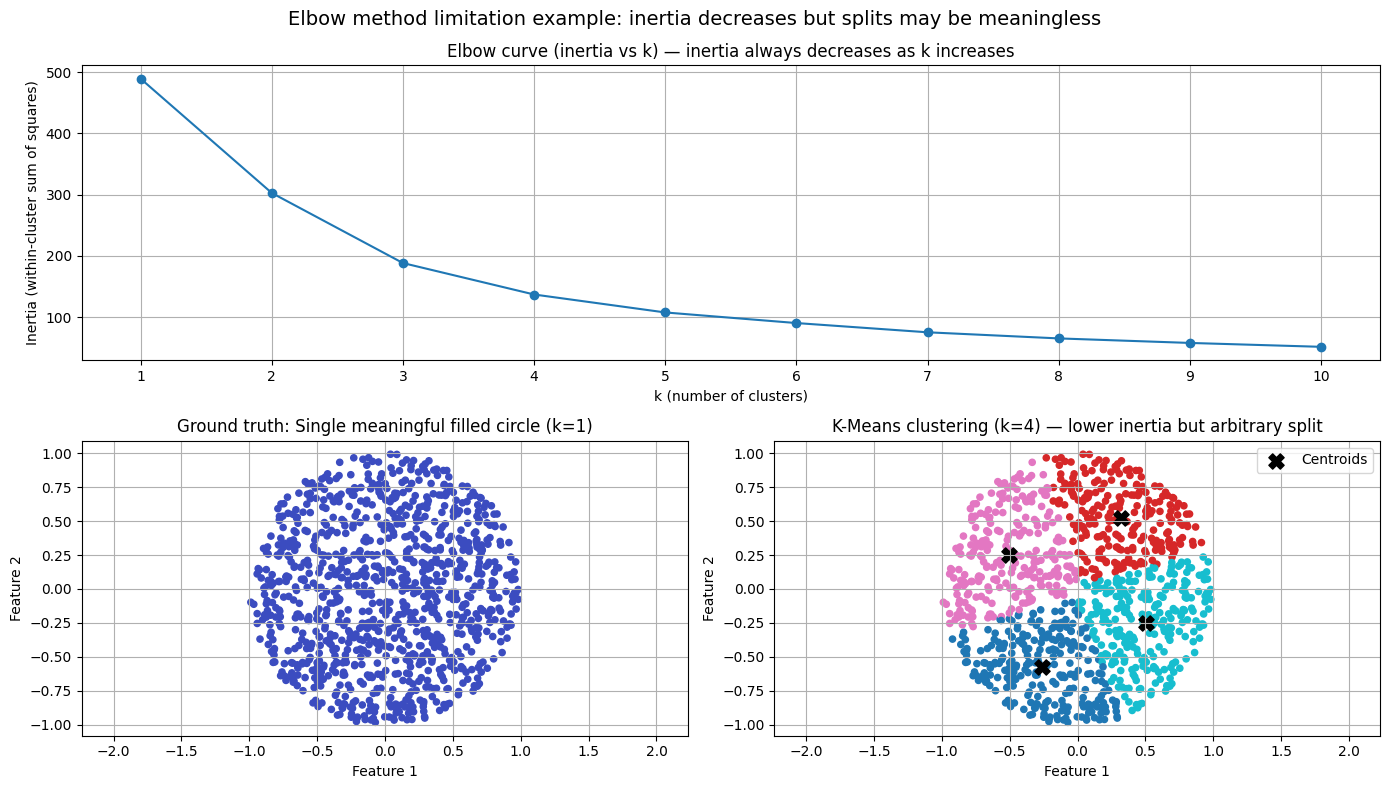

In [ ]:
# Generate filled circle (single meaningful cluster)

np.random.seed(42)
n_samples = 1000

# Uniformly sample points inside unit circle
r = np.sqrt(np.random.rand(n_samples))      # sqrt for uniform radial distribution
theta = 2 * np.pi * np.random.rand(n_samples)
x = r * np.cos(theta)
y = r * np.sin(theta)
X = np.column_stack((x, y))
y_true = np.zeros(n_samples, dtype=int)     # ground truth: single cluster


ks = list(range(1, 11))
inertias = []
kmeans_models = {}
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    kmeans_models[k] = km

# Choose a k suggested by eyeballing the elbow (here we pick k=4 to show arbitrary split)
k_chosen = 4
km_chosen = kmeans_models[k_chosen]
labels_chosen = km_chosen.labels_


# 3) Plot: elbow curve + ground truth vs chosen-k result
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2)

# Elbow plot (top-left spanning)
ax_elbow = fig.add_subplot(gs[0, :])
ax_elbow.plot(ks, inertias, marker='o')
ax_elbow.set_xticks(ks)
ax_elbow.set_xlabel("k (number of clusters)")
ax_elbow.set_ylabel("Inertia (within-cluster sum of squares)")
ax_elbow.set_title("Elbow curve (inertia vs k) — inertia always decreases as k increases")
ax_elbow.grid(True)

# Ground truth (bottom-left)
ax0 = fig.add_subplot(gs[1, 0])
ax0.scatter(X[:, 0], X[:, 1], c=y_true, cmap='coolwarm', s=20)
ax0.set_title("Ground truth: Single meaningful filled circle (k=1)")
ax0.set_xlabel("Feature 1")
ax0.set_ylabel("Feature 2")
ax0.axis('equal')
ax0.grid(True)

# KMeans result for chosen k (bottom-right)
ax1 = fig.add_subplot(gs[1, 1])
ax1.scatter(X[:, 0], X[:, 1], c=labels_chosen, cmap='tab10', s=20)
ax1.scatter(km_chosen.cluster_centers_[:, 0], km_chosen.cluster_centers_[:, 1],
            c='black', marker='X', s=120, label='Centroids')
ax1.set_title(f"K-Means clustering (k={k_chosen}) — lower inertia but arbitrary split")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.legend()
ax1.axis('equal')
ax1.grid(True)

plt.suptitle("Elbow method limitation example: inertia decreases but splits may be meaningless", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

## 5.Like K Means clustering itself, the results of elbow method can be sensitive to the scale of the data. Features with large scales can dominate the result, potentially leading to suboptimal choice of k.

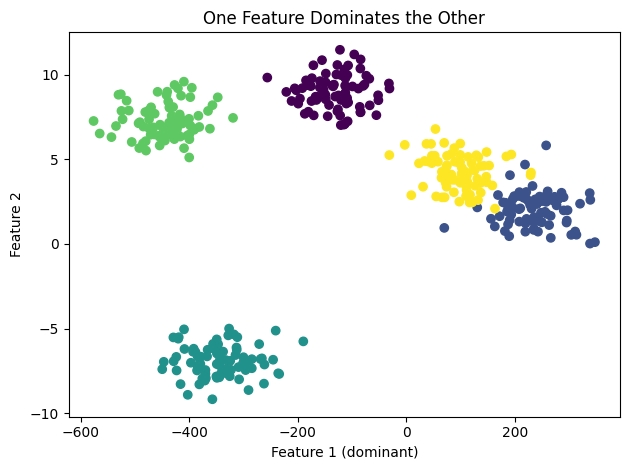

In [ ]:
X, y = make_blobs(n_samples = 400, n_features = 2, centers = 5, cluster_std = 1, random_state = 42)

# Make one feature dominate the other (e.g., scale feature 0 by a large factor)
X[:, 0] = X[:, 0] * 50  # Multiply Feature 0 by 50

# Visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("One Feature Dominates the Other")
plt.xlabel("Feature 1 (dominant)")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

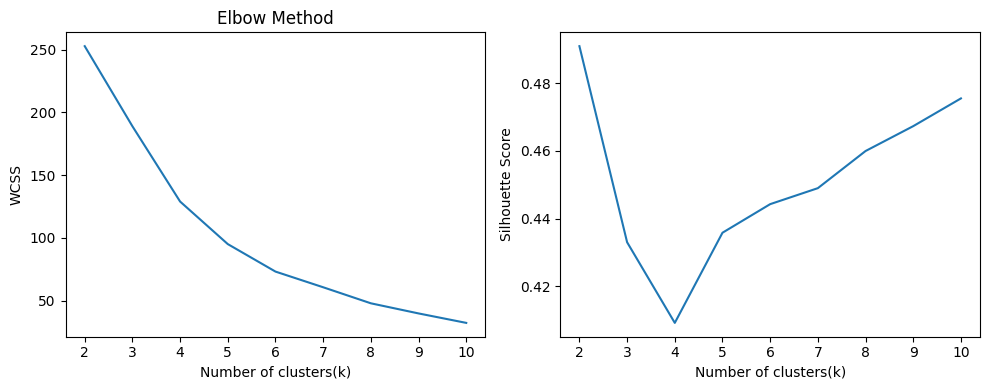

In [ ]:
X = df.values

wcss = []
sil_score = []

for k in range(2, 11):

    kmeans = KMeans(n_init = 10, n_clusters = k)
    y_labels = kmeans.fit_predict(X)

    wcss.append(kmeans.inertia_)
    sil_score.append(silhouette_score(X, labels = y_labels))


fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))

# Elbow Method
sns.lineplot(x = range(2,11), y =  wcss, ax = ax1)
ax1.set_xlabel('Number of clusters(k)')
ax1.set_ylabel('WCSS')
ax1.set_title('Elbow Method')

# Silhouette Score
sns.lineplot(x = range(2,11), y = sil_score, ax = ax2)
ax2.set_xlabel('Number of clusters(k)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

#Assumptions of K Means

## 1.K Means assumes that the clusters are spherical and isotropic, meaning they are uniform in all directions. The algo. work best when the clusters are are circular(in 2D) or spherical(in 3D) or hyper-spherical(in higher dimensions).

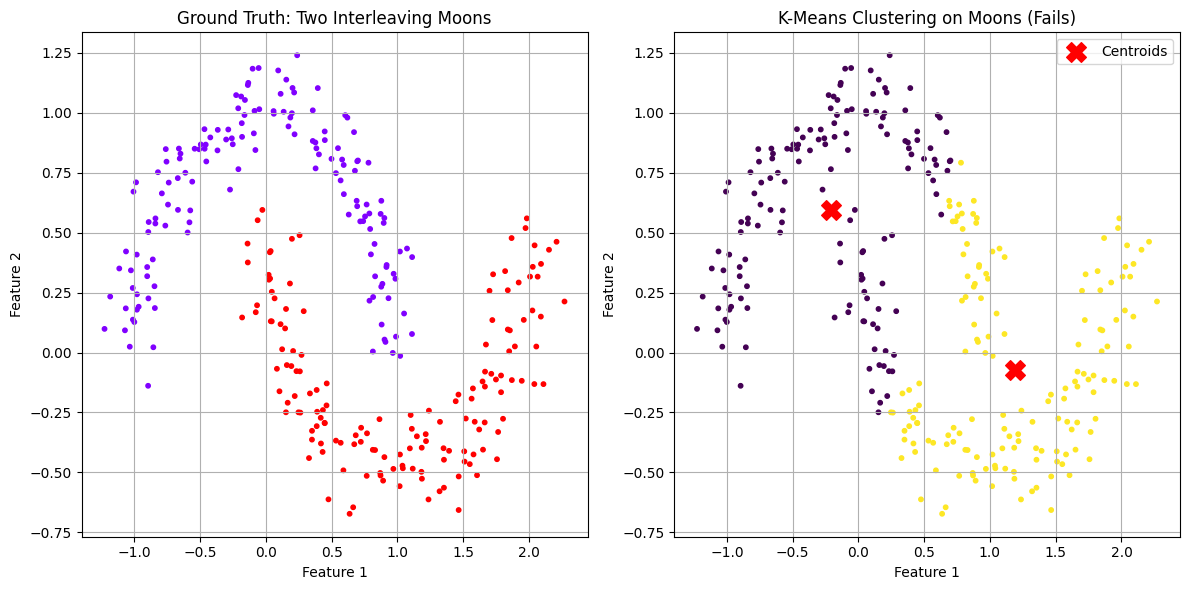

In [ ]:
X,y = make_moons(n_samples = 300, shuffle = True, noise = 0.1, random_state = 42)

# Fit KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# --- Plot 1: Ground Truth ---
axes[0].scatter(X[:, 0], X[:, 1], c = y, cmap = 'rainbow', s=10)
axes[0].set_title("Ground Truth: Two Interleaving Moons")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].grid(True)

# --- Plot 2: K-Means Result ---
axes[1].scatter(X[:, 0], X[:, 1], c = kmeans.labels_, cmap = 'viridis', s=10)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroids')
axes[1].set_title("K-Means Clustering on Moons (Fails)")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].grid(True)
axes[1].legend()

# Display the plots
plt.tight_layout()
plt.show()

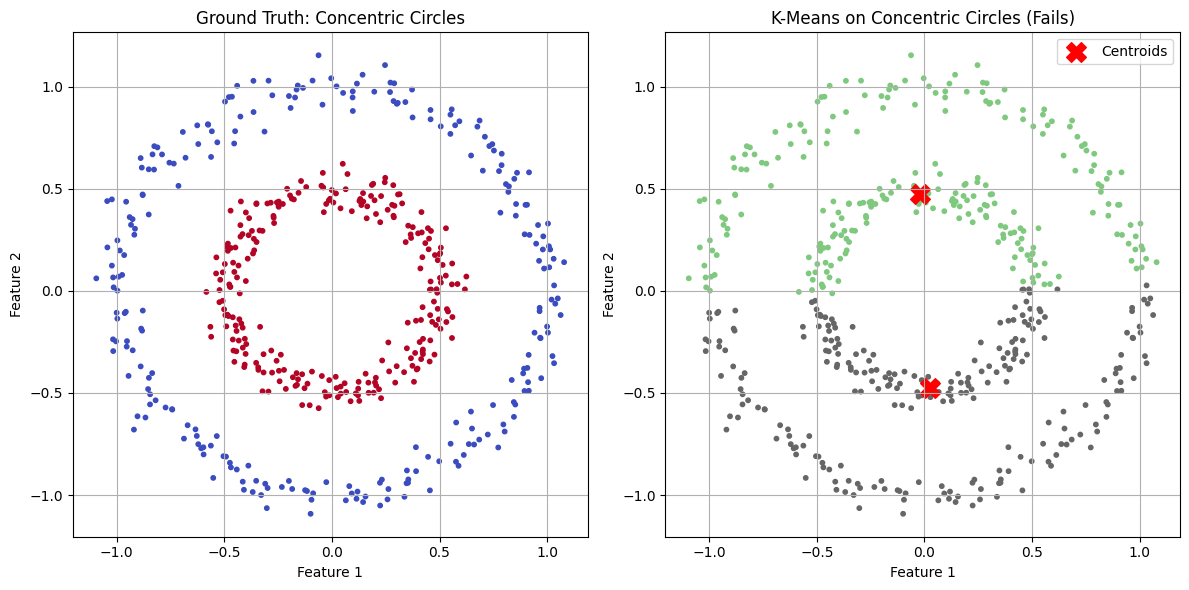

In [ ]:
# Generate concentric circles
X, y = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

# Fit KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# --- Plot 1: Ground Truth ---
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=10)
axes[0].set_title("Ground Truth: Concentric Circles")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].grid(True)

# --- Plot 2: K-Means Result ---
axes[1].scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='Accent', s=10)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],c='red', marker='X', s=200, label='Centroids')
axes[1].set_title("K-Means on Concentric Circles (Fails)")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].grid(True)
axes[1].legend()

# Display the plots
plt.tight_layout()
plt.show()

##2.K Means tends to perform better when all the clusters are of appoximately the same size. If one cluster is much larger than the others, K Means might struggle to correctly assign the points to the appropriate cluster.

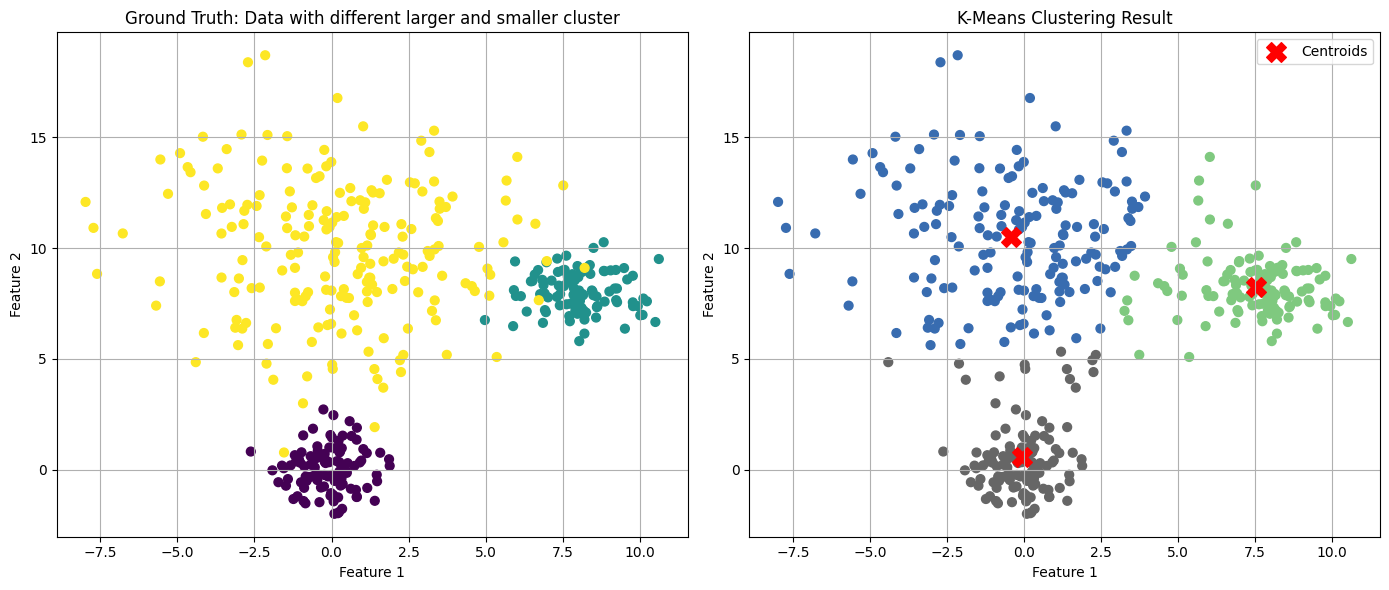

In [ ]:
# Define the parameters
centers = [(0, 0), (8, 8), (0, 10)]     # 3 clusters
cluster_std = [1.0, 1.0, 3.0]           # 3rd cluster is more spread
samples_per_cluster = [100, 100, 200]   # More samples in 3rd cluster

# Generate each cluster separately
X_parts = []
y_parts = []

for i, (center, std, n_samples) in enumerate(zip(centers, cluster_std, samples_per_cluster)):
    X_blob, _ = make_blobs(n_samples=n_samples, centers=[center], cluster_std=std, random_state=42 + i)
    X_parts.append(X_blob)
    y_parts.append(np.full(shape=n_samples, fill_value=i))

# Combine clusters
X = np.vstack(X_parts)
y = np.hstack(y_parts)

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# --- Plot 1: Ground Truth ---
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=40)
axes[0].set_title("Ground Truth: Data with different larger and smaller cluster")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].grid(True)

# --- Plot 2: K-Means Clustering Result ---
axes[1].scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='Accent', s=40)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='red', marker='X', s=200, label='Centroids')
axes[1].set_title("K-Means Clustering Result")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()
axes[1].grid(True)

# Display side-by-side plots
plt.tight_layout()
plt.show()

## 3.K Means assume that all the clusters have similar variance. The algorithm uses the Euclidean distance metric, which can be bias towards clusters with the lower variance.

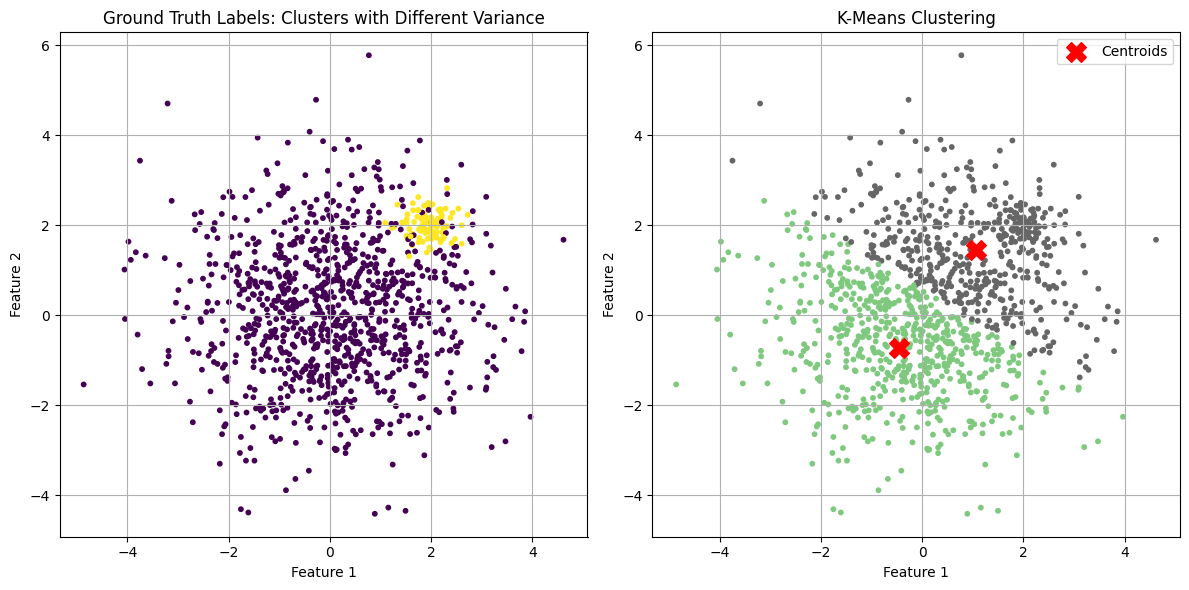

In [ ]:
# Generate clusters with different variances
X, y = make_blobs(
    n_samples=[1000, 100],
    centers=[[0, 0], [2, 2]],
    cluster_std=[1.5, 0.3],  # Different variances
    random_state=42
)

# Fit KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# --- Plot 1: Ground Truth ---
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=10)
axes[0].set_title("Ground Truth Labels: Clusters with Different Variance")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].grid(True)

# --- Plot 2: K-Means Result ---
axes[1].scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='Accent', s=10)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroids')
axes[1].set_title("K-Means Clustering")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].grid(True)
axes[1].legend()

# Display
plt.tight_layout()
plt.show()

## 4.K-Means works best when the clusters are well separated from each other. If clusters are overlapping , K Means might not be able to distinguish them effectively.

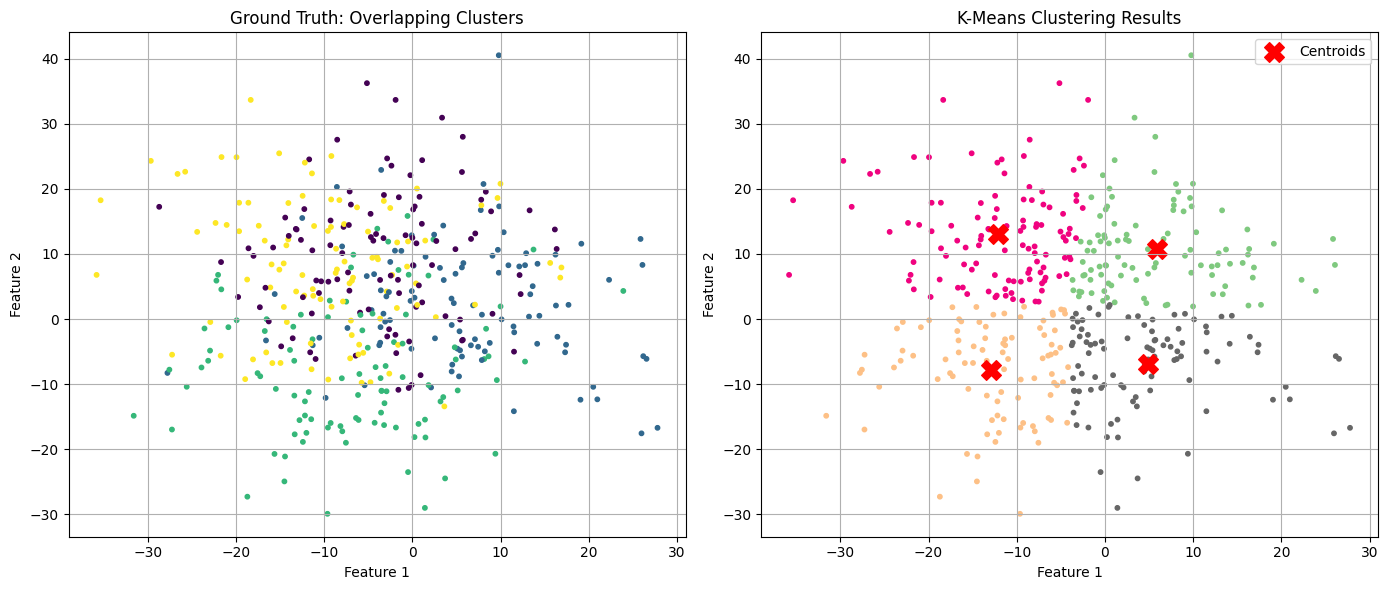

In [ ]:
# Generate blobs with high variance (std = 10)
X, y = make_blobs(n_samples=400, n_features=2, centers=4, cluster_std=10, random_state=42)

# Fit KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# --- Plot 1: Ground Truth ---
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=10)
axes[0].set_title("Ground Truth: Overlapping Clusters")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].grid(True)

# --- Plot 2: K-Means Result ---
axes[1].scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='Accent', s=10)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],c='red', marker='X', s=200, label='Centroids')
axes[1].set_title("K-Means Clustering Results")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()
axes[1].grid(True)

# Display
plt.tight_layout()
plt.show()

## 5.K Means is generally more efficient and effective when the dataset is large(large n) and the number of clusters is small(small k)

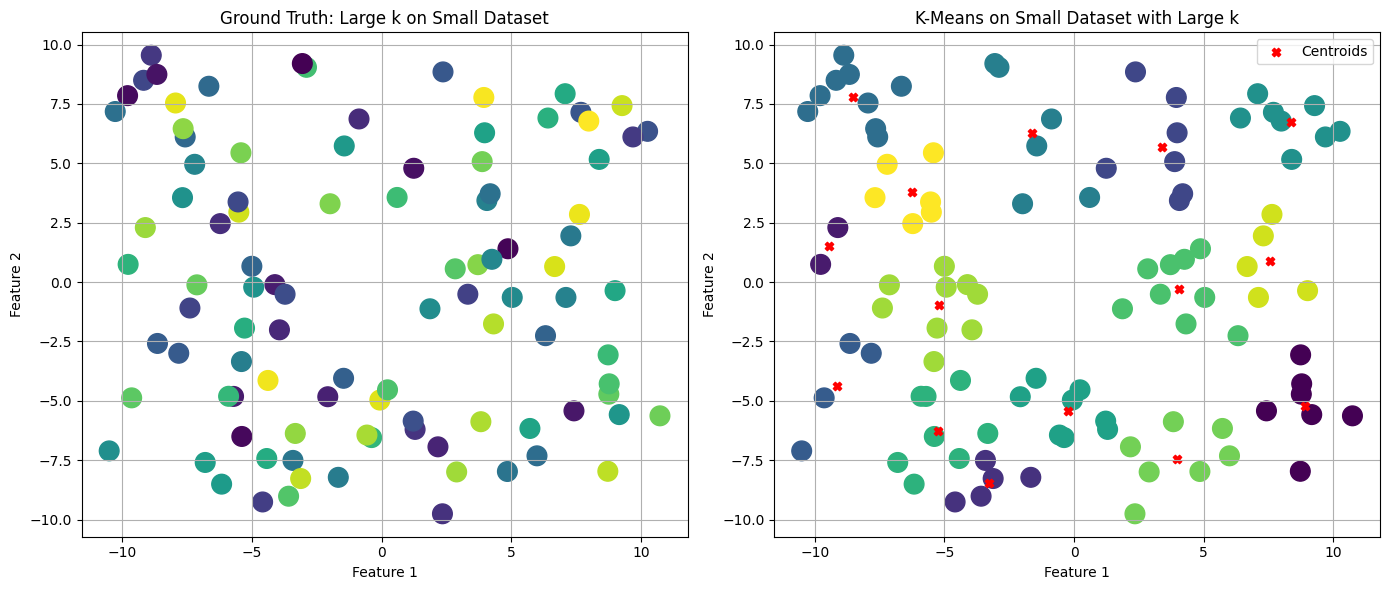

In [ ]:
# Generate a small dataset with too many clusters
X, y = make_blobs(n_samples = 100, n_features = 2, centers = 100, cluster_std = 0.8, random_state=42)

# Fit KMeans with k=15
kmeans = KMeans(n_clusters=15, random_state=42)
kmeans.fit(X)

# Create side-by-side plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# --- Plot 1: Ground Truth ---
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s = 200)
axes[0].set_title("Ground Truth: Large k on Small Dataset")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].grid(True)

# --- Plot 2: K-Means Result ---
axes[1].scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', s = 200)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', label='Centroids')
axes[1].set_title("K-Means on Small Dataset with Large k")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()
axes[1].grid(True)

# Show the plots
plt.tight_layout()
plt.show()

# Limitations of K Means

## 1.Determining the optimal number of clusters(k) is not straightforward and often required domain knowledge or methods like elbow method or silhouette score analysis.

## 2.Required clusters of similar sizes and similar variance

## 3.Assumption of isotrophic clusters

## 4.Vulnerability to outliers

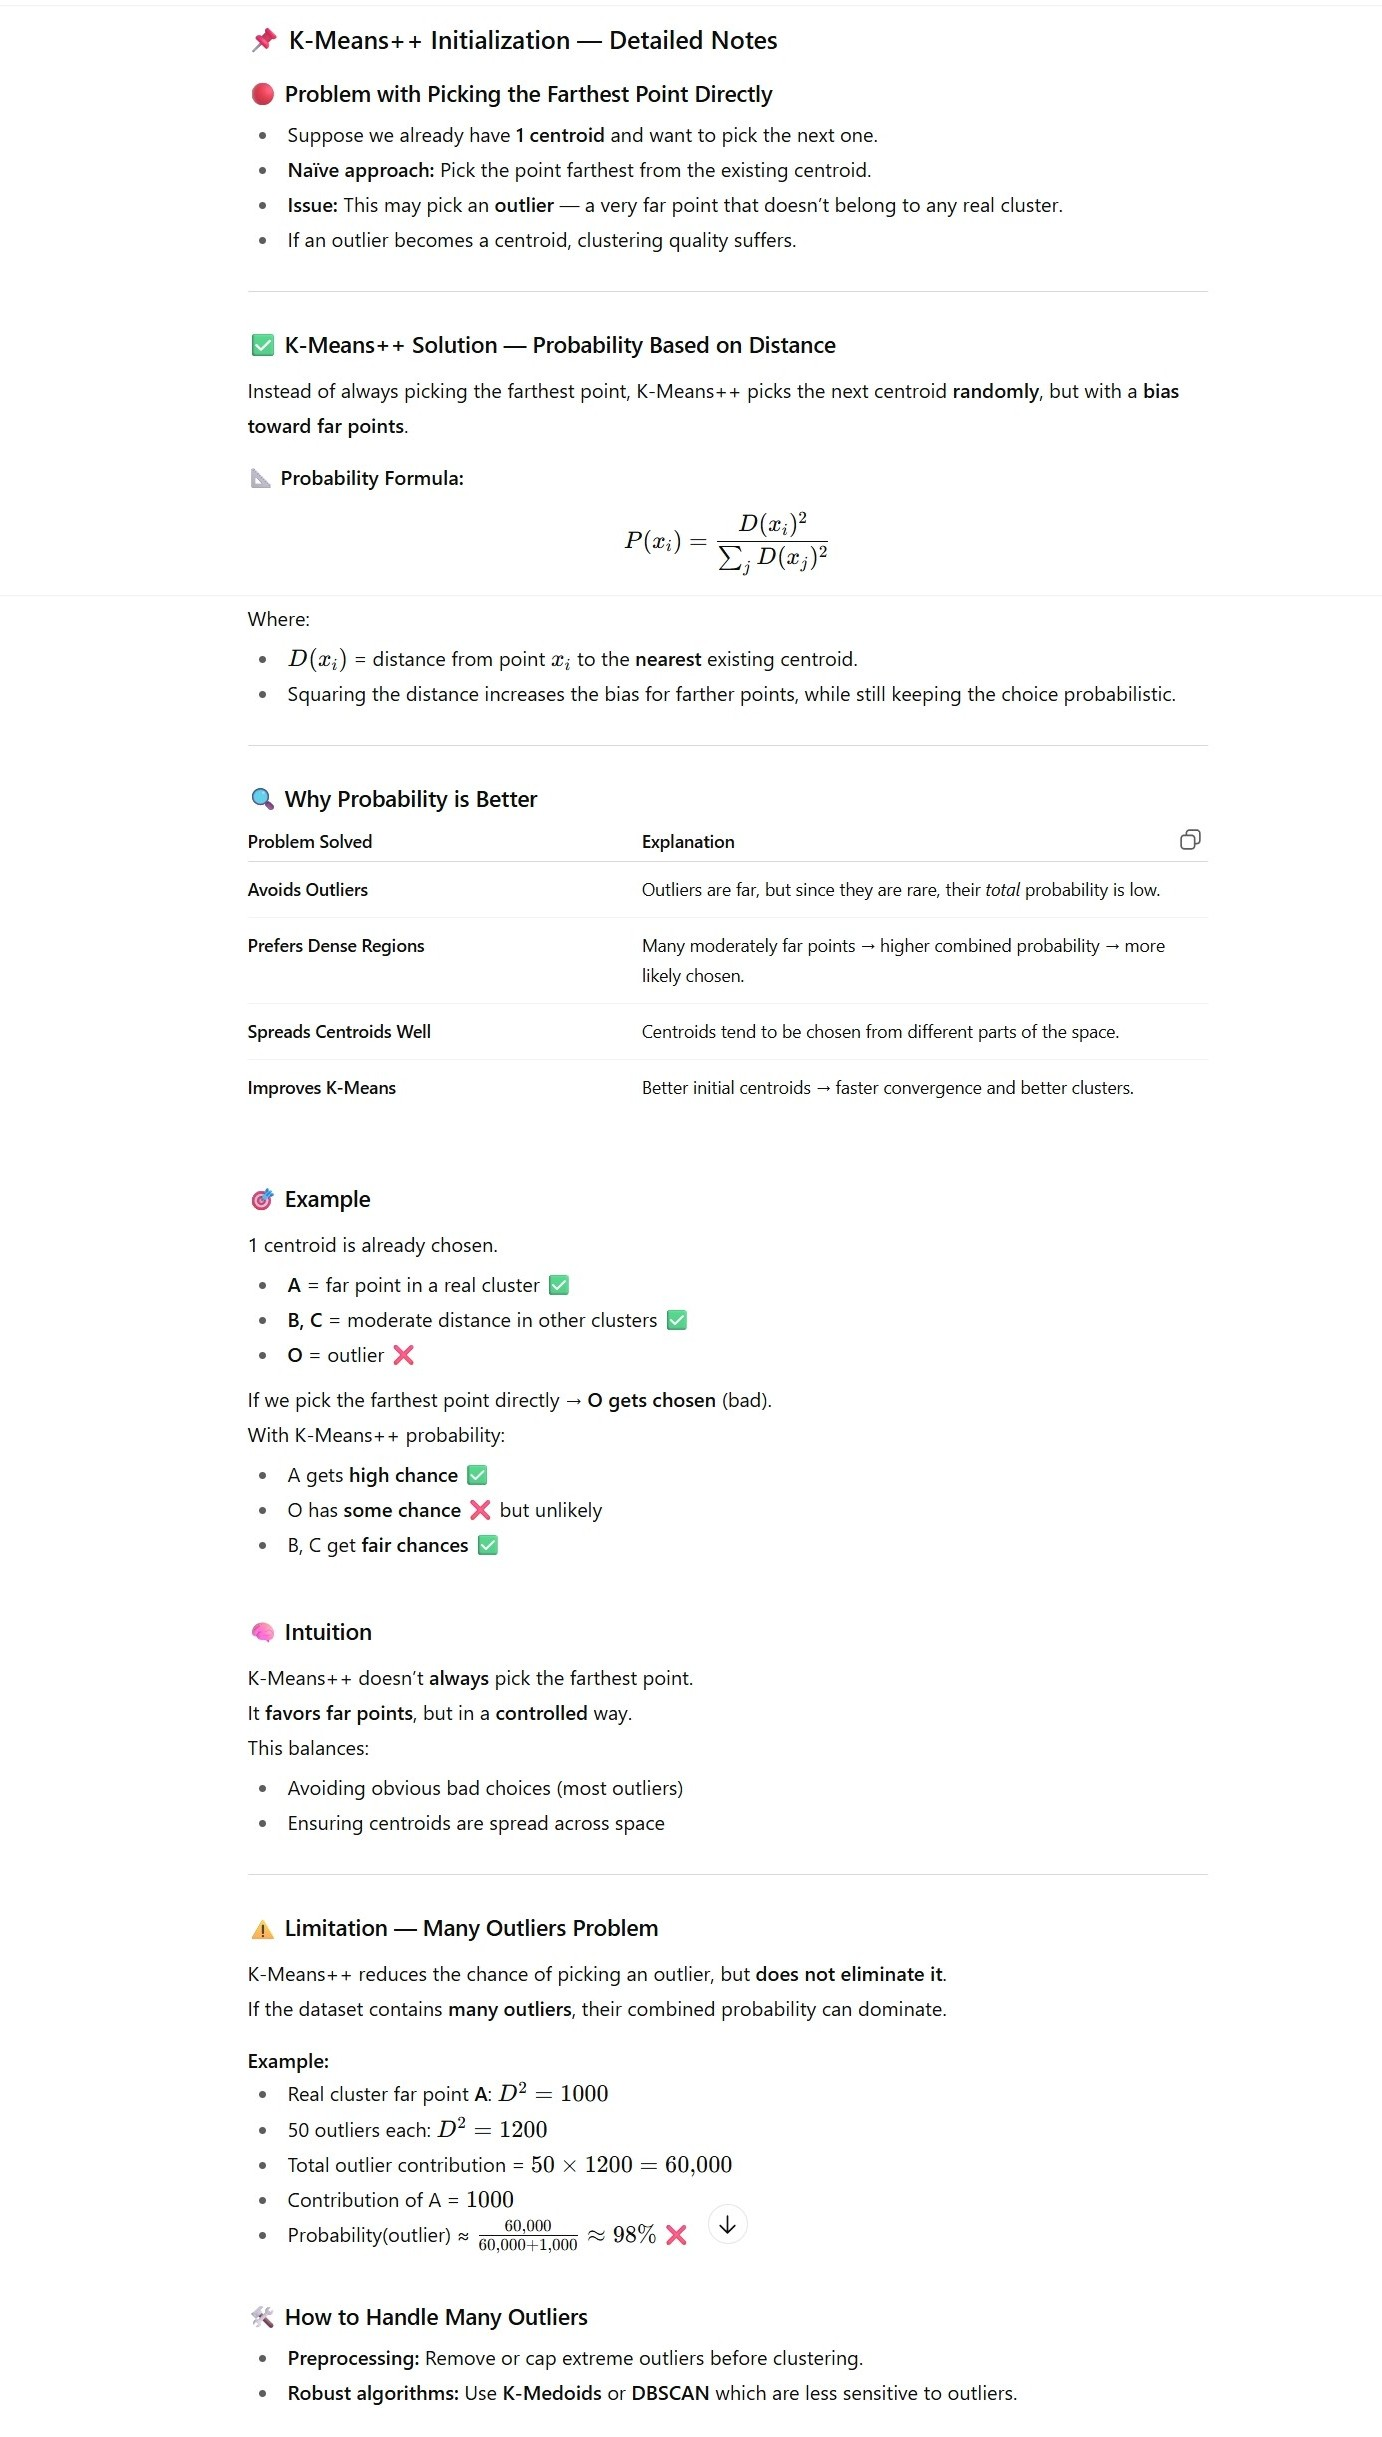

In [ ]:
from google.colab import drive
from PIL import Image

# Load and show image
image_path = '/content/K Means++.jpg'
image = Image.open(image_path)
display(image)

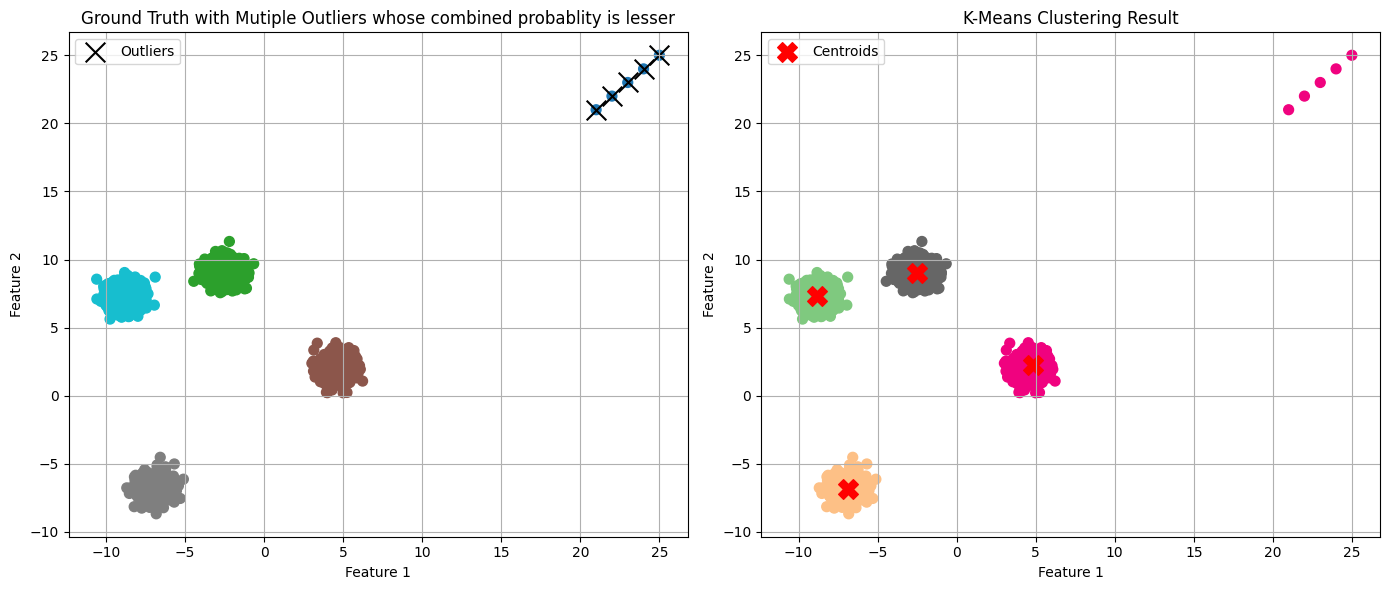

In [ ]:
# Generate clustered data
X, y = make_blobs(n_samples = 2000, n_features=2, centers=4, cluster_std = 0.6, random_state=42)

# Define 5 far-away outliers
outliers = np.array([
    [25, 25],
    [24, 24],
    [23, 23],
    [22, 22],
    [21, 21]
])

# Combine data and outliers
X_with_outliers = np.vstack([X, outliers])
y_with_outliers = np.append(y, [-1] * len(outliers))  # Label outliers as -1

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42, init = 'k-means++')
kmeans.fit(X_with_outliers)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# --- Plot 1: Ground Truth + Outliers ---
scatter1 = axes[0].scatter(X_with_outliers[:, 0], X_with_outliers[:, 1], c=y_with_outliers, cmap='tab10', s=50)
axes[0].scatter(outliers[:, 0], outliers[:, 1], color='black', marker='x', s=200, label='Outliers')
axes[0].set_title("Ground Truth with Mutiple Outliers whose combined probablity is lesser")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: K-Means Clustering Result ---
scatter2 = axes[1].scatter(X_with_outliers[:, 0], X_with_outliers[:, 1], c=kmeans.labels_, cmap='Accent', s=50)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='red', marker='X', s=200, label='Centroids')
axes[1].set_title("K-Means Clustering Result")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()
axes[1].grid(True)

# Display plots
plt.tight_layout()
plt.show()

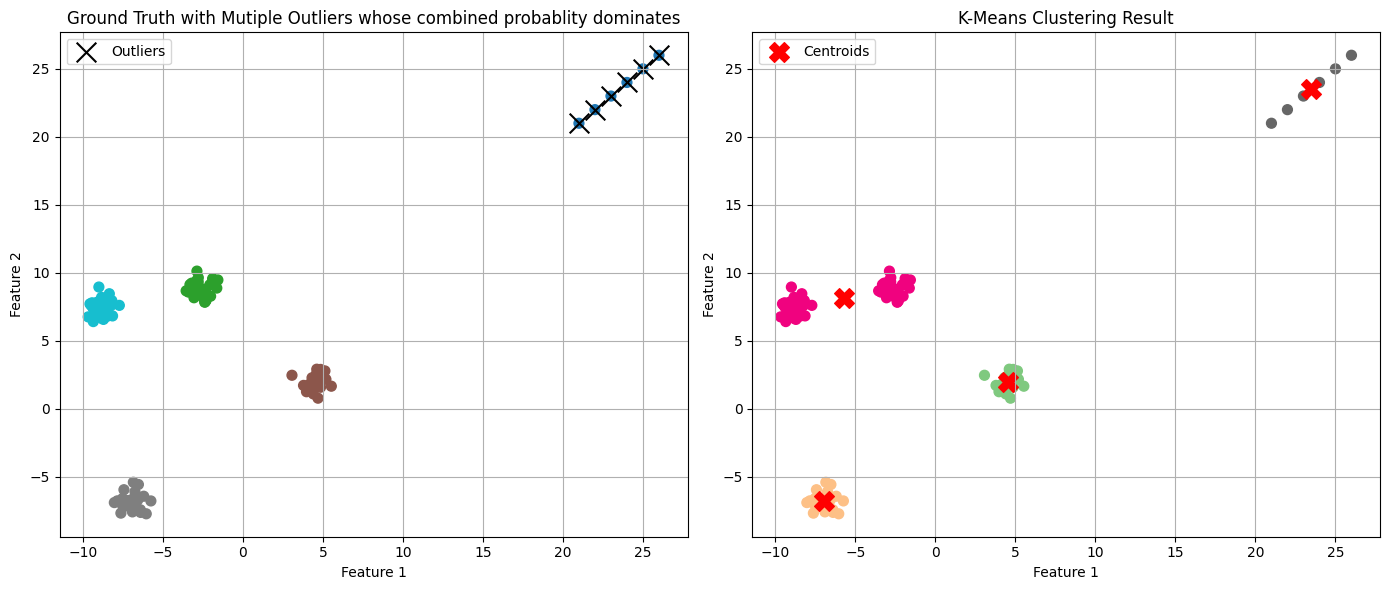

In [ ]:
# Generate clustered data
X, y = make_blobs(n_samples = 100, n_features=2, centers = 4, cluster_std=0.6, random_state=42)

outliers = np.array([
    [26, 26],
    [25, 25],
    [24, 24],
    [23, 23],
    [22, 22],
    [21, 21]
])

# Combine data and outliers
X_with_outliers = np.vstack([X, outliers])
y_with_outliers = np.append(y, [-1] * len(outliers))  # Label outliers as -1

# Apply KMeans
kmeans = KMeans(n_clusters = 4, random_state=42, init = 'k-means++')
kmeans.fit(X_with_outliers)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# --- Plot 1: Ground Truth + Outliers ---
scatter1 = axes[0].scatter(X_with_outliers[:, 0], X_with_outliers[:, 1], c=y_with_outliers, cmap='tab10', s=50)
axes[0].scatter(outliers[:, 0], outliers[:, 1], color='black', marker='x', s=200, label='Outliers')
axes[0].set_title("Ground Truth with Mutiple Outliers whose combined probablity dominates")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: K-Means Clustering Result ---
scatter2 = axes[1].scatter(X_with_outliers[:, 0], X_with_outliers[:, 1], c=kmeans.labels_, cmap='Accent', s=50)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='red', marker='X', s=200, label='Centroids')
axes[1].set_title("K-Means Clustering Result")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()
axes[1].grid(True)

# Display plots
plt.tight_layout()
plt.show()

## 5.Hard Clustering : Each data point is forced into exactly one cluster, which may not be suitable for all applications, especially where the data can belong to mutiple clusters.

## 6.High Dimensional Challenges : In high dimensional spaces, the euclidian distance b/w data points can become less meaningful, affectng the performance of K Means

## 7.Sensitive to Scale : The K Means result is sensitive to the scale of the features. Hence feature scaling is often recommended before applying K Means

# Graphical Representation of Silhouette Score

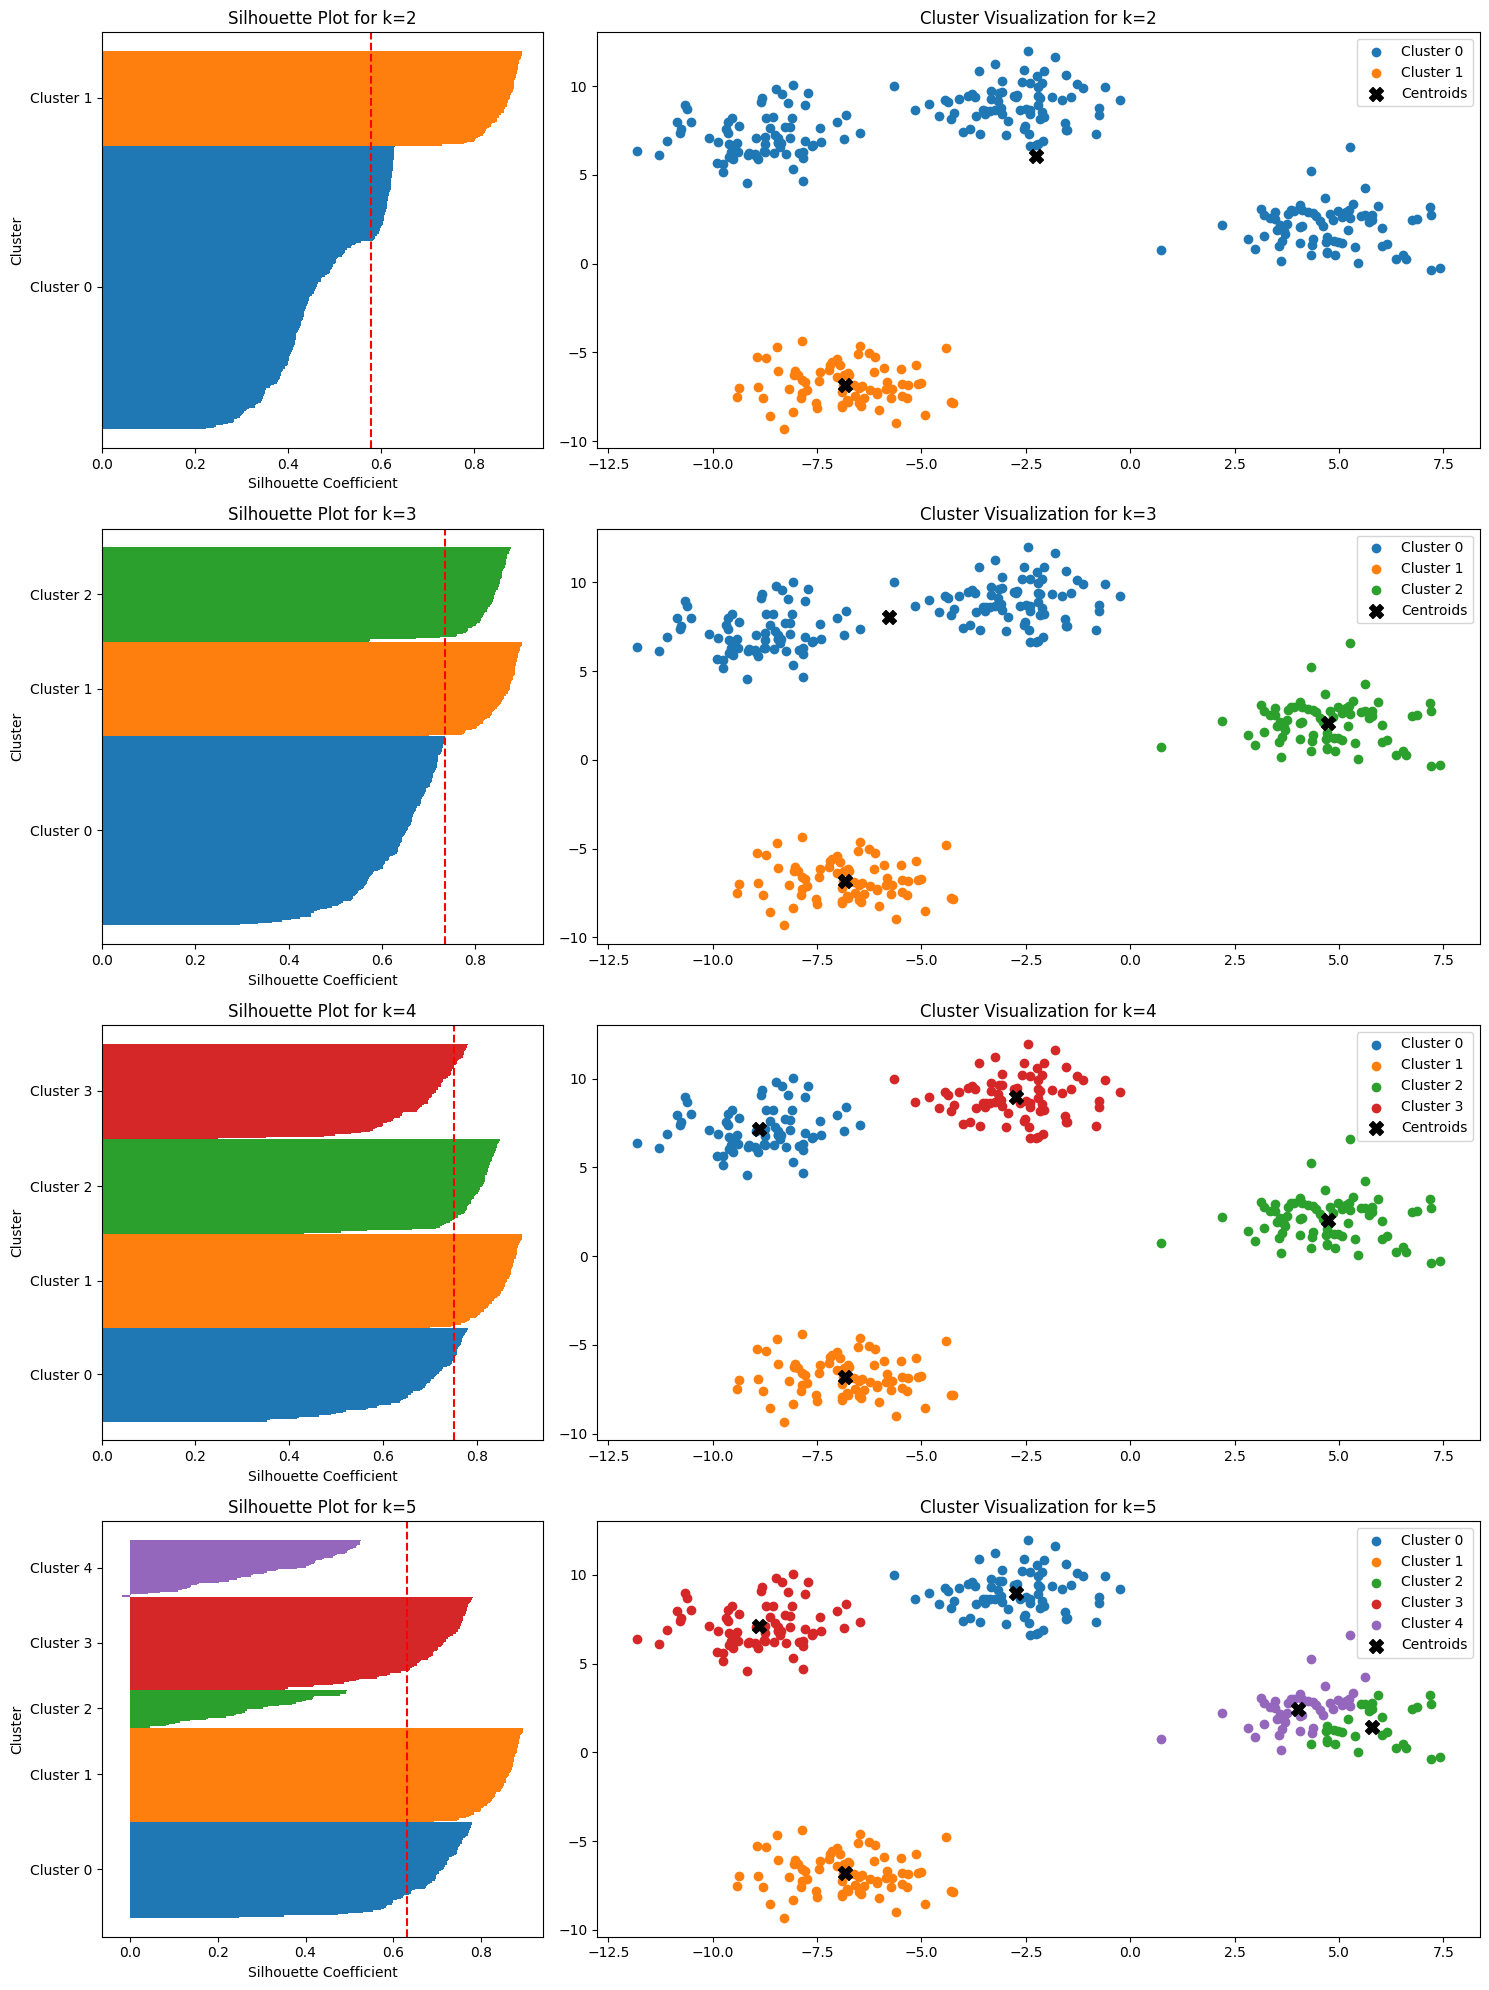

In [ ]:
import matplotlib.gridspec as gridspec
from sklearn.metrics import silhouette_samples, silhouette_score

X, y = make_blobs(n_samples = 300, n_features = 2, centers = 4, cluster_std = 1.2, random_state=42)

# Setting up the subplot grid
fig = plt.figure(figsize=(15, 20))
gs = gridspec.GridSpec(4, 2, width_ratios=[1, 2])

# Creating silhouette and scatter plots for different values of k (2, 3, 4, 5)
for i, k in enumerate([2, 3, 4, 5]):
    # Clustering with k-means
    kmeans = KMeans(n_init=10, n_clusters=k, random_state=10)
    cluster_labels = kmeans.fit_predict(X)

    # Silhouette values
    silhouette_vals = silhouette_samples(X, cluster_labels)
    avg_score = silhouette_score(X, cluster_labels)

    # Silhouette plot
    ax1 = plt.subplot(gs[i, 0])
    y_lower, y_upper = 0, 0
    yticks = []
    for j, cluster in enumerate(np.unique(cluster_labels)):
        cluster_silhouette_vals = silhouette_vals[cluster_labels == cluster]
        cluster_silhouette_vals.sort()
        y_upper += len(cluster_silhouette_vals)
        ax1.barh(range(y_lower, y_upper), cluster_silhouette_vals, edgecolor='none', height=1)
        yticks.append((y_lower + y_upper) / 2)
        y_lower += len(cluster_silhouette_vals)
    ax1.axvline(avg_score, color="red", linestyle="--")
    ax1.set_yticks(yticks)
    ax1.set_yticklabels([f'Cluster {x}' for x in np.unique(cluster_labels)])
    ax1.set_ylabel('Cluster')
    ax1.set_xlabel('Silhouette Coefficient')
    ax1.set_title(f'Silhouette Plot for k={k}')

    # Scatter plot
    ax2 = plt.subplot(gs[i, 1])
    for j in np.unique(cluster_labels):
        ax2.scatter(X[cluster_labels == j, 0], X[cluster_labels == j, 1], label=f'Cluster {j}')
    ax2.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='black', marker='X', label='Centroids')
    ax2.set_title(f'Cluster Visualization for k={k}')
    ax2.legend()

plt.tight_layout()
plt.show()

# k = 4 is best among the others

# Limitation of Silhouette Score


1. Silhouette Score is biased toward well-separated clusters

2. Even if two groups belong together logically but are a little close, silhouette might penalize them.

3. It may prefer a clustering where groups are artificially split just because they are farther apart.

4. Some real-world datasets naturally have overlapping clusters (e.g., customer groups, biological data, social behavior).
These overlaps might be:
 - Due to fuzzy boundaries between groups
 - An inherent part of the data
 - Even if your clustering captures this meaningful overlap well, the Silhouette Score will be low, because it assumes that good clusters should be clearly separated.

5. A low score might suggest "bad clustering", even though the clusters make sense contextually.

6. It makes you think "more separation = better clustering", which is not always true in real data.


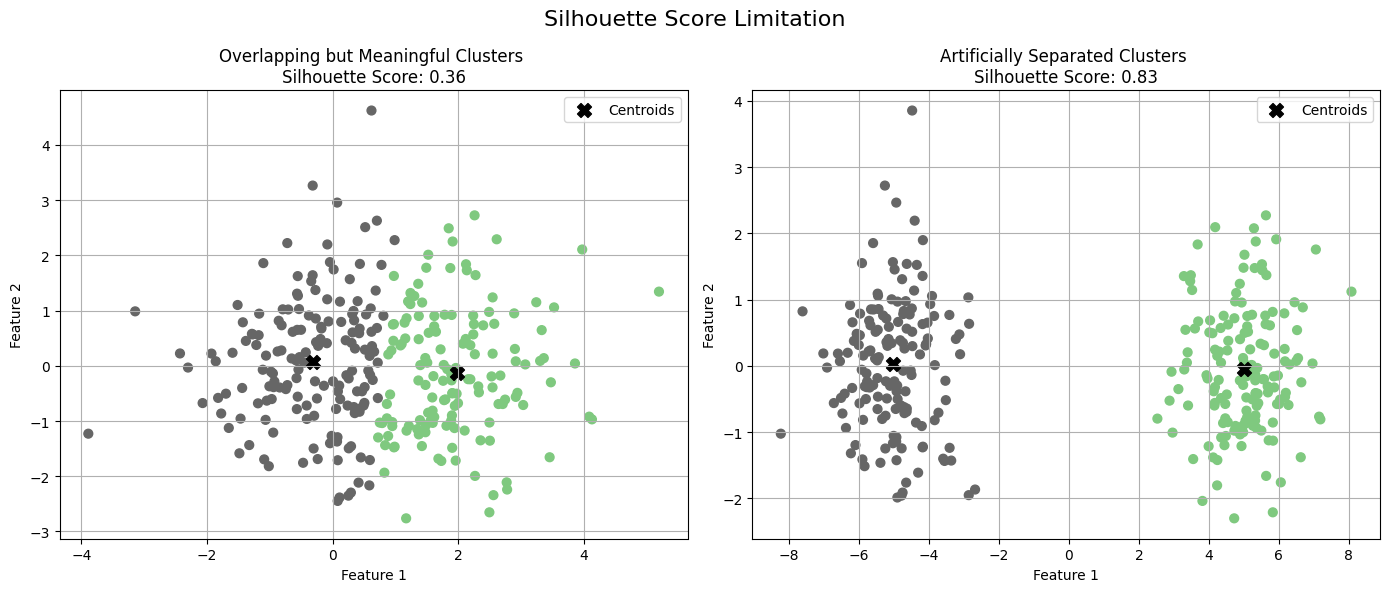

In [ ]:
# --- Dataset 1: Overlapping but Meaningful Clusters ---
X1, y1 = make_blobs(n_samples=300, centers=[[0, 0], [1.5, 0]], cluster_std=1.2, random_state=42)
kmeans1 = KMeans(n_clusters=2, random_state=42).fit(X1)
score1 = silhouette_score(X1, kmeans1.labels_).round(2)

# --- Dataset 2: Artificially Separated Clusters ---
X2, y2 = make_blobs(n_samples=300, centers=[[-5, 0], [5, 0]], cluster_std=1.0, random_state=42)
kmeans2 = KMeans(n_clusters=2, random_state=42).fit(X2)
score2 = silhouette_score(X2, kmeans2.labels_).round(2)

# --- Plotting ---
fig, axes = plt.subplots(ncols=2, figsize=(14, 6))
fig.suptitle("Silhouette Score Limitation", fontsize=16)

# Plot 1: Overlapping but Meaningful
axes[0].scatter(X1[:, 0], X1[:, 1], c=kmeans1.labels_, cmap='Accent', s=40)
axes[0].scatter(kmeans1.cluster_centers_[:, 0], kmeans1.cluster_centers_[:, 1],color='black', marker='X', s=100, label='Centroids')
axes[0].set_title(f"Overlapping but Meaningful Clusters \nSilhouette Score: {score1}")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].legend()
axes[0].grid(True)

# Plot 2: Artificially Separated
axes[1].scatter(X2[:, 0], X2[:, 1], c=kmeans2.labels_, cmap='Accent', s=40)
axes[1].scatter(kmeans2.cluster_centers_[:, 0], kmeans2.cluster_centers_[:, 1], color='black', marker='X', s=100, label='Centroids')
axes[1].set_title(f"Artificially Separated Clusters \nSilhouette Score: {score2}")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()